# Visualización Gráfica de Datos ECG

Este notebook carga y visualiza gráficamente las columnas del archivo CSV `11-08-2025, 07_50_22-1.csv`.

In [1]:
# Importar bibliotecas necesarias
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Configurar matplotlib para gráficos inline
%matplotlib inline

In [2]:
# Cargar el archivo CSV
df = pd.read_csv('../11-08-2025, 14_30_21-1.csv')
print("Primeras 5 filas del DataFrame:")
print(df.head())
print("\nInformación del DataFrame:")
print(df.info())

Primeras 5 filas del DataFrame:
        UNIX Timestamp    ECG  HR  RR  Marker
0  1754897422768994635 -0.047 NaN NaN     NaN
1  1754897422776680502  0.461 NaN NaN     NaN
2  1754897422784366369  1.164 NaN NaN     NaN
3  1754897422792052236  1.211 NaN NaN     NaN
4  1754897422799738103  0.469 NaN NaN     NaN

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 468295 entries, 0 to 468294
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   UNIX Timestamp  468295 non-null  int64  
 1   ECG             468295 non-null  float64
 2   HR              3148 non-null    float64
 3   RR              4510 non-null    float64
 4   Marker          0 non-null       float64
dtypes: float64(4), int64(1)
memory usage: 17.9 MB
None


In [3]:
# Convertir timestamp a datetime
df['UNIX Timestamp'] = pd.to_datetime(df['UNIX Timestamp'], unit='ns')
df.set_index('UNIX Timestamp', inplace=True)

print("DataFrame con timestamp convertido:")
print(df.head())

DataFrame con timestamp convertido:
                                 ECG  HR  RR  Marker
UNIX Timestamp                                      
2025-08-11 07:30:22.768994635 -0.047 NaN NaN     NaN
2025-08-11 07:30:22.776680502  0.461 NaN NaN     NaN
2025-08-11 07:30:22.784366369  1.164 NaN NaN     NaN
2025-08-11 07:30:22.792052236  1.211 NaN NaN     NaN
2025-08-11 07:30:22.799738103  0.469 NaN NaN     NaN


In [4]:
# Seleccionar rango de tiempo (opcional)
# Cambia estos valores para ajustar el rango de visualización
start_time = df.index.min()  # Inicio del dataset
end_time = start_time + pd.Timedelta(minutes=1000)  # Primeros 10 minutos, cambia a 20 para 20 minutos

# Para seleccionar un rango específico, descomenta y ajusta:
# start_time = pd.Timestamp('2025-08-11 06:50:00')  # Hora específica de inicio
# end_time = pd.Timestamp('2025-08-11 07:00:00')    # Hora específica de fin

df_filtered = df.loc[start_time:end_time]
print(f"Datos filtrados: {len(df_filtered)} filas de {len(df)} totales")
print(f"Rango temporal: {start_time} a {end_time}")
print(f"Duración: {(end_time - start_time).total_seconds() / 60:.1f} minutos")

Datos filtrados: 468295 filas de 468295 totales
Rango temporal: 2025-08-11 07:30:22.768994635 a 2025-08-12 00:10:22.768994635
Duración: 1000.0 minutos


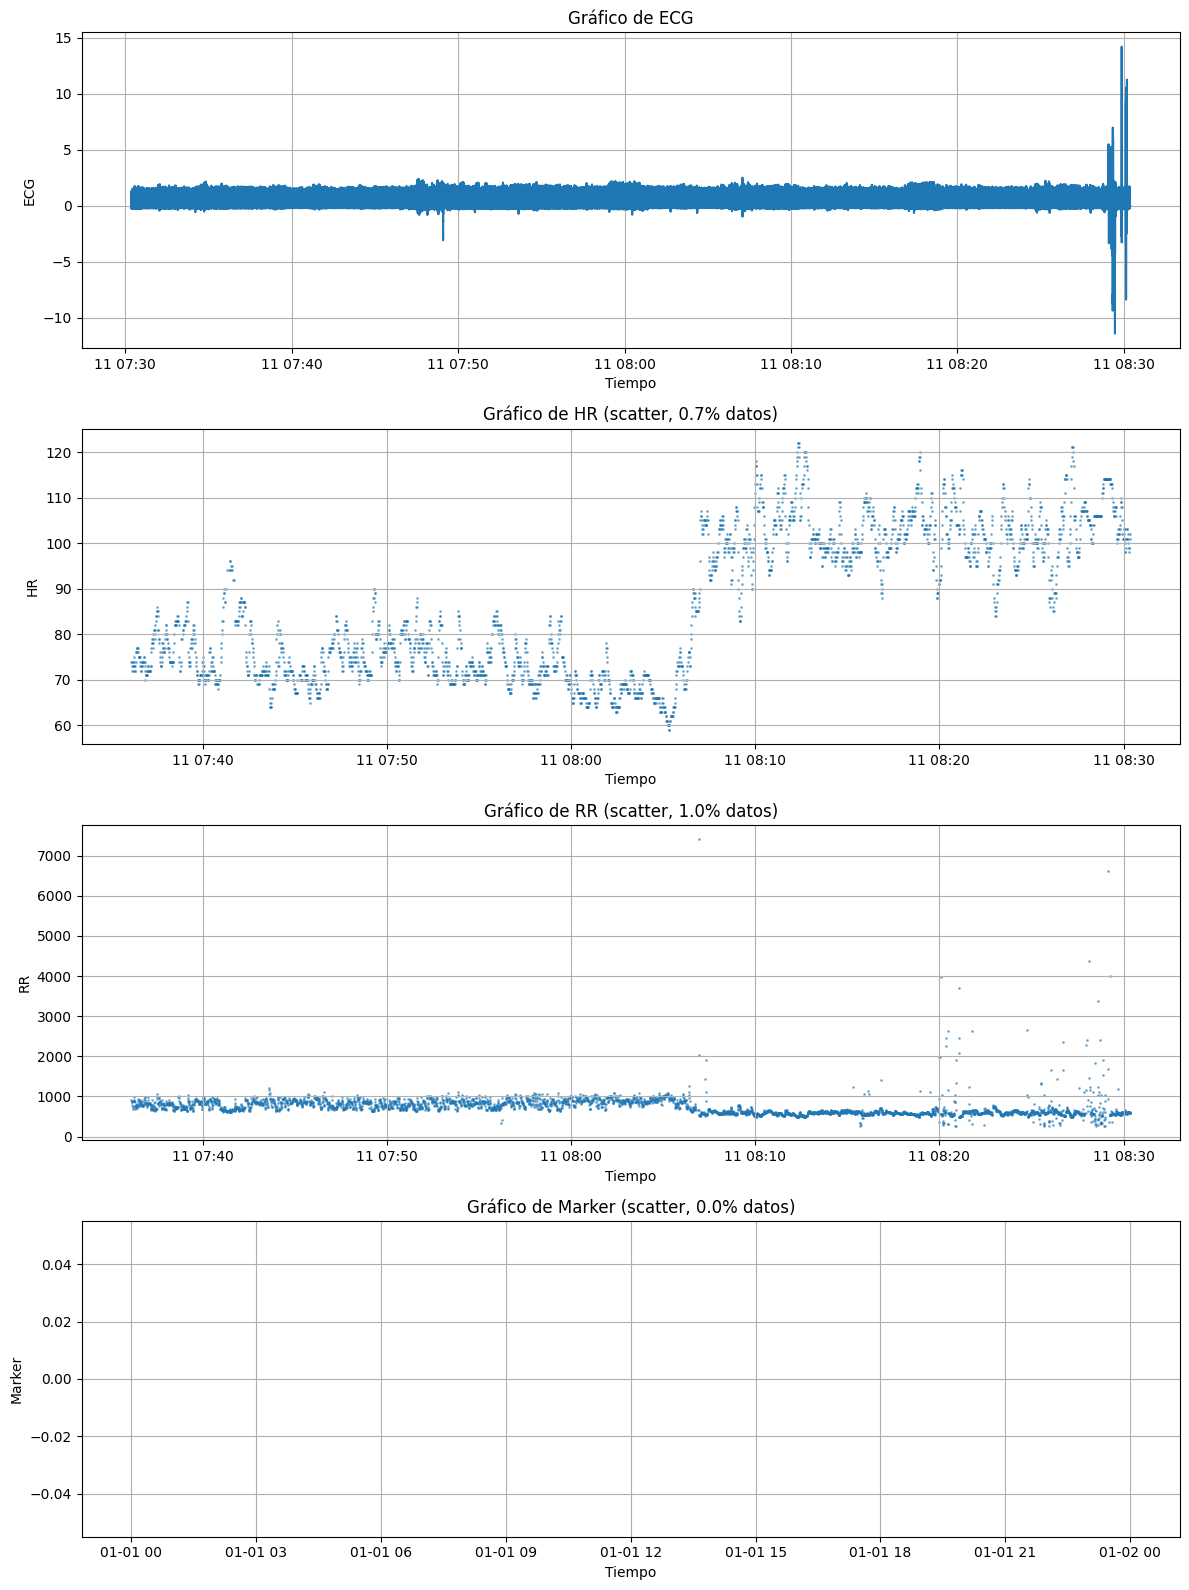

In [5]:
# Graficar todas las columnas numéricas
numeric_columns = df_filtered.select_dtypes(include=['float64', 'int64']).columns

fig, axes = plt.subplots(len(numeric_columns), 1, figsize=(12, 4 * len(numeric_columns)))
if len(numeric_columns) == 1:
    axes = [axes]

for i, col in enumerate(numeric_columns):
    # Calcular porcentaje de valores no nulos
    non_null_pct = df_filtered[col].notna().sum() / len(df_filtered) * 100
    
    if non_null_pct < 10:  # Si menos del 10% tiene datos, usar scatter
        axes[i].scatter(df_filtered.index, df_filtered[col], s=1, alpha=0.5)
        axes[i].set_title(f'Gráfico de {col} (scatter, {non_null_pct:.1f}% datos)')
    else:
        axes[i].plot(df_filtered.index, df_filtered[col])
        axes[i].set_title(f'Gráfico de {col}')
    
    axes[i].set_xlabel('Tiempo')
    axes[i].set_ylabel(col)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

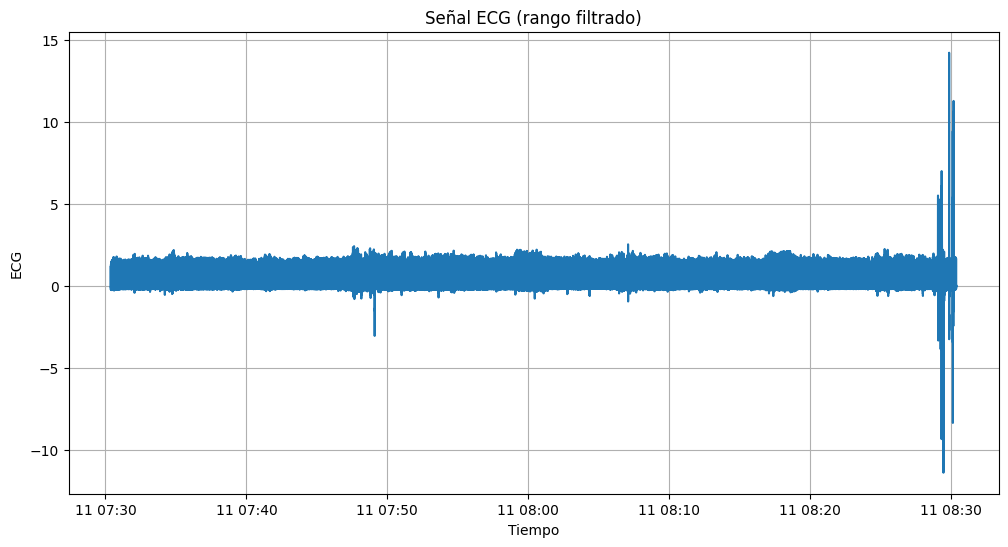

In [6]:
# Graficar ECG específicamente (si existe)
if 'ECG' in df_filtered.columns:
    plt.figure(figsize=(12, 6))
    plt.plot(df_filtered.index, df_filtered['ECG'])
    plt.title('Señal ECG (rango filtrado)')
    plt.xlabel('Tiempo')
    plt.ylabel('ECG')
    plt.grid(True)
    plt.show()

In [7]:
# Estadísticas descriptivas del rango filtrado
print("Estadísticas descriptivas del rango filtrado:")
print(df_filtered.describe())

Estadísticas descriptivas del rango filtrado:
                 ECG           HR           RR  Marker
count  468295.000000  3148.000000  4510.000000     0.0
mean       -0.011553    86.167090   721.892905     NaN
std         0.335784    15.626033   250.685350     NaN
min       -11.407000    59.000000   260.000000     NaN
25%        -0.091000    72.000000   587.000000     NaN
50%        -0.059000    82.000000   669.000000     NaN
75%        -0.024000   101.000000   838.000000     NaN
max        14.219000   122.000000  7410.000000     NaN
